|                |   |
:----------------|---|
| **Nombre**     | Valeria Guzmán Galván, Sebastián Ochoa Sánchez  y Santiago Alvarez Tostado Estrada|
| **Fecha**      | 13/04/2026  |

# **Análisis y comparación de modelos de clasificación para la predicción del riesgo crediticio mediante optimización bayesiana**

## **Objetivos**

### Objetivo General

Analizar y comparar el desempeño de modelos de clasificación de aprendizaje automático para la predicción del riesgo crediticio (incumplimiento de pago), mediante la optimización de sus hiperparámetros utilizando técnicas de optimización bayesiana, con el fin de mejorar su capacidad predictiva.

### Objetivos Específicos

Realizar un análisis exploratorio del conjunto de datos para identificar su estructura, distribución de variables y el comportamiento de la variable objetivo.

Diseñar un pipeline de preprocesamiento que incluya la limpieza de datos, tratamiento de valores atípicos, codificación de variables categóricas y escalamiento de variables numéricas.

Implementar modelos de clasificación supervisada, tales como regresión logística con regularización, máquinas de vectores de soporte con kernel RBF y redes neuronales tipo multi-layer perceptron.

Optimizar los hiperparámetros de los modelos mediante técnicas de optimización bayesiana basadas en procesos gaussianos, con el objetivo de mejorar su desempeño predictivo.

Evaluar el desempeño de los modelos utilizando validación cruzada (k-fold cross-validation) y métricas de clasificación adecuadas para datos desbalanceados, como F1.

Comparar el desempeño de los modelos y analizar sus resultados para identificar cuál ofrece la mejor capacidad de predicción del riesgo de incumplimiento de pago.

## **Marco Teórico**

**Regresión Logística**

La regresión logística es un modelo de clasificación binaria que permite estimar la probabilidad de que una observación pertenezca a una clase, a partir de una combinación lineal de variables independientes transformada mediante una función sigmoide (James et al., 2023).

Este modelo es ampliamente utilizado en el análisis de riesgo crediticio, ya que permite interpretar cómo influyen distintas variables en la probabilidad de incumplimiento. Además, puede incorporar regularización para evitar el sobreajuste y mejorar su capacidad de generalización (Murphy, 2012).


**Máquinas de Vectores de Soporte (SVM)**

Las máquinas de vectores de soporte (SVM) son algoritmos de clasificación que buscan separar los datos mediante un hiperplano que maximiza el margen entre clases (Cortes & Vapnik, 1995). Cuando la relación no es lineal, utilizan kernels como el RBF. Sus parámetros principales son C, que controla el error, y γ, que define la flexibilidad del modelo.

**Kernels (RBF)**

Los kernels permiten modelar relaciones no lineales sin transformar explícitamente los datos, usando el llamado kernel trick (Bishop, 2006). El kernel RBF es uno de los más usados porque se adapta bien a patrones complejos.

**Redes Neuronales (Multi-Layer Perceptron)**

El perceptrón multicapa (MLP) es un modelo de redes neuronales compuesto por múltiples capas de neuronas artificiales, capaz de aprender patrones complejos y altamente no lineales (Goodfellow et al., 2016). Es flexible, pero puede sobreajustarse si no se ajustan bien sus hiperparámetros.

**Métricas para Clasificación**

Las métricas de clasificación permiten evaluar el desempeño de los modelos. Entre las más relevantes se encuentran el F1-score y el área bajo la curva ROC (AUC), las cuales son especialmente útiles en problemas financieros donde existe desbalance entre clases (James et al., 2023).

Estas métricas permiten medir la capacidad del modelo para identificar correctamente tanto clientes con buen comportamiento como aquellos con riesgo de impago.

**Hiperparámetros**

Los hiperparámetros son valores que se definen antes de entrenar el modelo y afectan su desempeño, como la regularización o la estructura de una red neuronal (Murphy, 2012).

**Optimización Bayesiana**

La optimización bayesiana permite encontrar buenos hiperparámetros de forma eficiente, explorando el espacio de búsqueda de manera inteligente y reduciendo el número de pruebas necesarias (Rasmussen & Williams, 2006).

## **Tema elegido para proyecto**

Este proyecto se enfoca en el análisis del riesgo crediticio de solicitantes de préstamos personales, con el objetivo de predecir la probabilidad de incumplimiento de pago (default) mediante un enfoque de clasificación binaria.

Para ello, se utilizarán variables relacionadas con el historial crediticio, las condiciones del préstamo y la situación financiera del cliente. A partir de esta información, se implementarán distintos modelos, como regresión logística, SVM y redes neuronales, con el fin de comparar su desempeño en la clasificación de clientes según su nivel de riesgo.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Preprocesamiento y modelado
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Métricas
from sklearn.metrics import classification_report, f1_score, roc_auc_score, confusion_matrix

# Optimización Bayesiana
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

In [ ]:
df = pd.read_csv("loan_data.csv")

df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [ ]:
df.shape

(45000, 14)

In [ ]:
df['loan_status'].value_counts()
df['loan_status'].value_counts(normalize=True)

loan_status
0    0.777778
1    0.222222
Name: proportion, dtype: float64

## **Análisis del dataset**

El conjunto de datos utilizado en este proyecto fue obtenido de Kaggle y creado por Tawei Lo. Se trata de un dataset sintético, inspirado en el “Credit Risk Dataset” y ampliado con variables adicionales mediante la técnica SMOTENC.

El dataset contiene 45,000 registros y 14 variables que describen características financieras y del historial crediticio de los solicitantes. Se identifican 9 variables numéricas y 5 categóricas, por lo que se requiere aplicar técnicas de preprocesamiento como codificación y escalamiento.

La variable objetivo, loan_status, indica si el cliente incumple el pago. Se observa un desbalance de clases (78% clase 0 y 22% clase 1), por lo que se utilizarán métricas como AUC y F1-score.

Para el modelado, las variables categóricas se transformarán mediante One-Hot Encoding y las numéricas serán escaladas. También se consideran posibles outliers y variables derivadas como loan_percent_income.

Dado que es un dataset sintético, los resultados pueden no reflejar completamente situaciones reales. El objetivo es predecir el riesgo de incumplimiento y comparar el desempeño de distintos modelos de clasificación.

## **Preprocesamiento y Pipeline**

In [ ]:
df.duplicated().sum()

np.int64(0)

*Se separa la variable objetivo y las variables predictoras*

In [ ]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

*Se definen transformaciones para variables numéricas (imputación y escalamiento) y categóricas (imputación y codificación One-Hot)*

In [ ]:
num_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
            'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']

cat_cols = ['person_gender', 'person_education', 'person_home_ownership',
            'loan_intent', 'previous_loan_defaults_on_file']

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

*Se divide el dataset en train y test con muestreo estratificado.*
*Se construye un pipeline que integra el preprocesamiento y el modelo para evitar fugas de información*

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

## **Modelo 1. Regresión Logística con Optimización Bayesiana**

Se optimizan los hiperparámetros de la regresión logística (C y tipo de regularización) mediante optimización bayesiana para mejorar el desempeño del modelo.

In [ ]:
search_space_lr = {
    'classifier__C': Real(1e-4, 1e2, prior='log-uniform'),
    'classifier__penalty': Categorical(['l1', 'l2']),
    'classifier__solver': Categorical(['liblinear'])
}

opt_lr = BayesSearchCV(
    pipeline_lr,
    search_spaces=search_space_lr,
    n_iter=15,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

opt_lr.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,search_spaces,"{'classifier__C': Real(low=0.00...m='normalize'), 'classifier__penalty': Categorical(c...), prior=None), 'classifier__solver': Categorical(c...), prior=None)}"
,optimizer_kwargs,None
,n_iter,15
,scoring,'f1'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


In [ ]:
print("Mejores parámetros:", opt_lr.best_params_)
print(f"Mejor F1 en validación: {opt_lr.best_score_:.4f}")

Mejores parámetros: OrderedDict([('classifier__C', 0.24766757078523782), ('classifier__penalty', 'l1'), ('classifier__solver', 'liblinear')])
Mejor F1 en validación: 0.7397


In [ ]:
y_pred_lr = opt_lr.predict(X_test)

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      7000
           1       0.62      0.92      0.74      2000

    accuracy                           0.86      9000
   macro avg       0.80      0.88      0.82      9000
weighted avg       0.90      0.86      0.87      9000



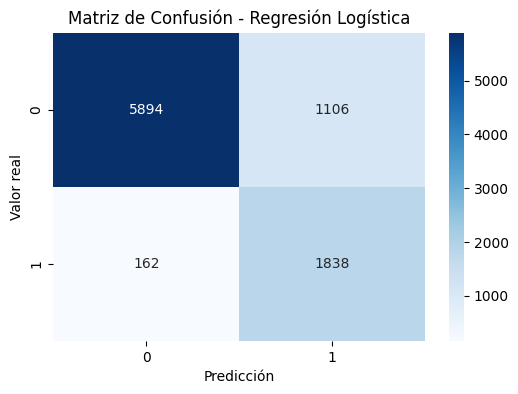

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

El modelo presenta un buen desempeño, con un F1-score cercano a 0.74.

Se observa un alto recall en la clase de incumplimiento (0.92), lo que indica que el modelo identifica correctamente a la mayoría de los clientes con riesgo. Sin embargo, la precisión es menor (0.62), lo que implica la presencia de falsos positivos.

En este contexto, el modelo es adecuado, ya que en problemas de riesgo crediticio es preferible identificar a los clientes riesgosos, incluso si se cometen algunos errores.

## **Modelo 2. Máquina de Vectores de Soporte (SVM) con Optimización Bayesiana**

Se optimizan los hiperparámetros del modelo SVM con kernel RBF (C y gamma) mediante optimización bayesiana para mejorar su desempeño.

In [ ]:
pipeline_svm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', class_weight='balanced', random_state=42))
])

In [ ]:
search_space_svm = {
    'classifier__C': Real(1e-3, 1e2, prior='log-uniform'),
    'classifier__gamma': Real(1e-4, 1e1, prior='log-uniform')
}

opt_svm = BayesSearchCV(
    pipeline_svm,
    search_spaces=search_space_svm,
    n_iter=10,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

opt_svm.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,search_spaces,"{'classifier__C': Real(low=0.00...m='normalize'), 'classifier__gamma': Real(low=0.00...m='normalize')}"
,optimizer_kwargs,None
,n_iter,10
,scoring,'f1'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


In [ ]:
print("Mejores parámetros:", opt_svm.best_params_)
print(f"Mejor F1 en validación: {opt_svm.best_score_:.4f}")

Mejores parámetros: OrderedDict([('classifier__C', 9.948719998234102), ('classifier__gamma', 0.01549337141764052)])
Mejor F1 en validación: 0.7584


In [ ]:
y_pred_svm = opt_svm.predict(X_test)

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_svm))

cm_svm = confusion_matrix(y_test, y_pred_svm)


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      7000
           1       0.64      0.93      0.76      2000

    accuracy                           0.87      9000
   macro avg       0.81      0.89      0.83      9000
weighted avg       0.90      0.87      0.88      9000



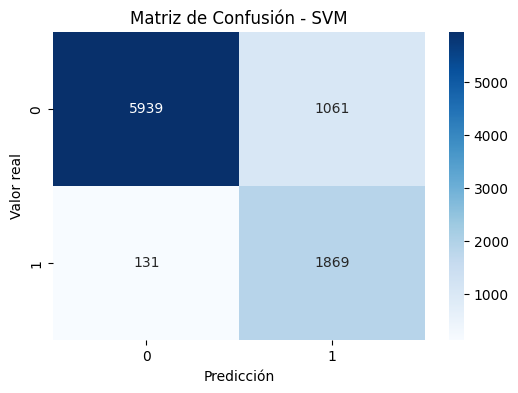

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - SVM")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

El modelo SVM presenta un buen desempeño, con un F1-score cercano a 0.76.

Se observa un alto recall en la clase de incumplimiento (0.93), lo que indica que el modelo identifica correctamente a la mayoría de los clientes con riesgo. Sin embargo, la precisión es menor (0.64), lo que implica la presencia de falsos positivos.

En general, el modelo mejora respecto a la regresión logística al capturar relaciones no lineales, aunque presenta un menor equilibrio entre precisión y recall en comparación con el MLP.

## **Modelo 3. Red Neuronal (Perceptrón Multicapa) con Optimización Bayesiana**

Se optimizan los hiperparámetros del modelo MLP mediante optimización bayesiana para mejorar su desempeño.

In [ ]:
pipeline_mlp = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(max_iter=500, early_stopping=True, random_state=42))
])

In [ ]:
search_space_mlp = {
    'classifier__activation': Categorical(['relu', 'tanh']),
    'classifier__alpha': Real(1e-5, 1e-1, prior='log-uniform'),
    'classifier__learning_rate_init': Real(1e-4, 1e-2, prior='log-uniform'),
    'classifier__solver': Categorical(['adam'])
}

opt_mlp = BayesSearchCV(
    pipeline_mlp,
    search_spaces=search_space_mlp,
    n_iter=15,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

opt_mlp.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,search_spaces,"{'classifier__activation': Categorical(c...), prior=None), 'classifier__alpha': Real(low=1e-0...m='normalize'), 'classifier__learning_rate_init': Real(low=0.00...m='normalize'), 'classifier__solver': Categorical(c...), prior=None)}"
,optimizer_kwargs,None
,n_iter,15
,scoring,'f1'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


In [ ]:
print("Mejores parámetros:", opt_mlp.best_params_)
print(f"Mejor F1 en validación: {opt_mlp.best_score_:.4f}")

Mejores parámetros: OrderedDict([('classifier__activation', 'relu'), ('classifier__alpha', 0.007686348671446863), ('classifier__learning_rate_init', 0.01), ('classifier__solver', 'adam')])
Mejor F1 en validación: 0.8063


In [ ]:
y_pred_mlp = opt_mlp.predict(X_test)

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_mlp))

cm_mlp = confusion_matrix(y_test, y_pred_mlp)


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7000
           1       0.85      0.78      0.82      2000

    accuracy                           0.92      9000
   macro avg       0.90      0.87      0.88      9000
weighted avg       0.92      0.92      0.92      9000



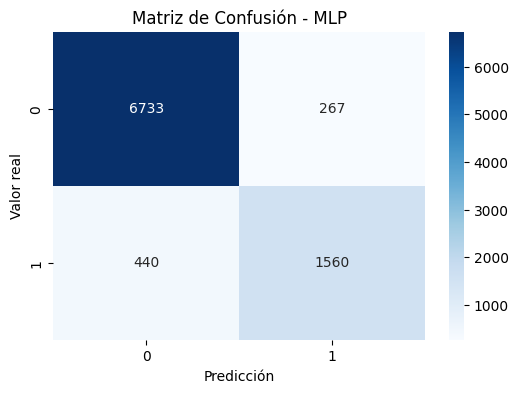

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - MLP")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

El modelo MLP presenta el mejor desempeño, con un F1-score cercano a 0.82.

Se observa una alta precisión (0.85) y un buen recall (0.78) en la clase de incumplimiento, lo que indica un mejor equilibrio entre la detección de clientes riesgosos y la reducción de falsos positivos.

En comparación con los modelos anteriores, el MLP logra capturar patrones más complejos en los datos, lo que se traduce en una mejor capacidad predictiva.

## **Pipeline**

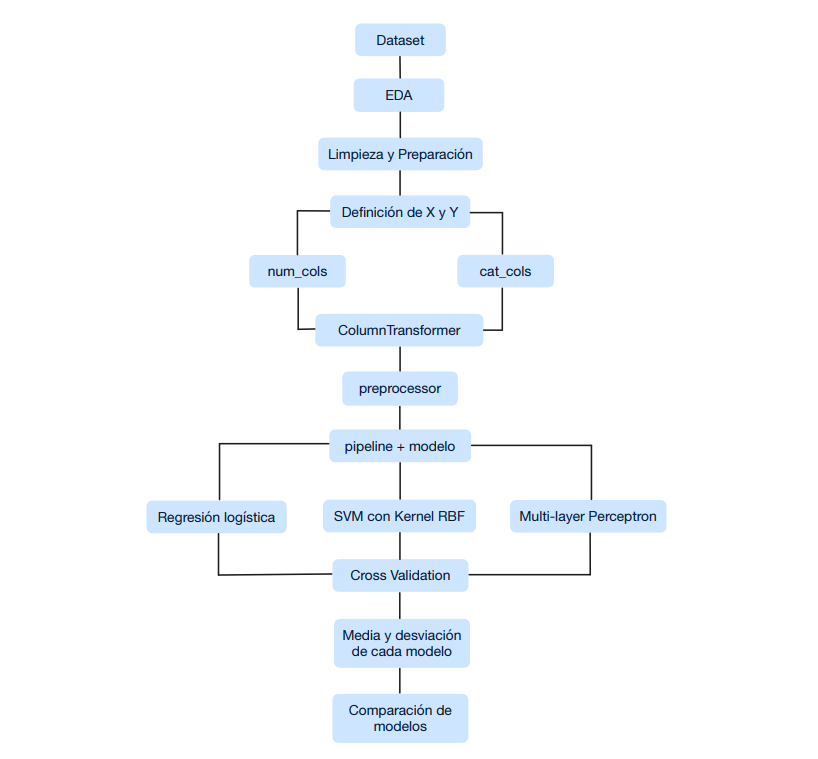

## **Comparación de modelos mediante validación cruzada**

Se realiza validación cruzada estratificada (k=10) utilizando los mejores modelos obtenidos previamente, con el fin de evaluar su desempeño general.

Se emplea el F1-score como métrica principal, calculando la media y la desviación estándar para cada modelo.

In [ ]:
best_lr = opt_lr.best_estimator_
best_mlp = opt_mlp.best_estimator_
best_svm = opt_svm.best_estimator_

In [ ]:
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scores_lr = cross_val_score(
    best_lr, X, y,
    cv=kfold,
    scoring='f1',
    n_jobs=-1
)

scores_mlp = cross_val_score(
    best_mlp, X, y,
    cv=kfold,
    scoring='f1',
    n_jobs=-1
)

scores_svm = cross_val_score(
    best_svm, X, y,
    cv=kfold,
    scoring='f1',
    n_jobs=-1
)

*Cálculo de media y desviación estándar*

In [ ]:
print("Resultados de validación cruzada (F1):\n")

print(f"Regresión Logística | Media: {scores_lr.mean():.4f}  | Desviación estándar: {scores_lr.std():.4f}")
print(f"MLP                 | Media: {scores_mlp.mean():.4f} | Desviación estándar: {scores_mlp.std():.4f}")
print(f"SVM RBF             | Media: {scores_svm.mean():.4f} | Desviación estándar: {scores_svm.std():.4f}")

Resultados de validación cruzada (F1):

Regresión Logística | Media: 0.7408  | Desviación estándar: 0.0063
MLP                 | Media: 0.8070 | Desviación estándar: 0.0119
SVM RBF             | Media: 0.7587 | Desviación estándar: 0.0053


*Tabla comparativa final*

In [ ]:
resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'MLP', 'SVM RBF'],
    'Media F1': [scores_lr.mean(), scores_mlp.mean(), scores_svm.mean()],
    'Desv_std_F1': [scores_lr.std(), scores_mlp.std(), scores_svm.std()]
})

resultados = resultados.sort_values(by='Media F1', ascending=False).reset_index(drop=True)

print(resultados)

                Modelo  Media F1  Desv_std_F1
0                  MLP  0.807019     0.011859
1              SVM RBF  0.758674     0.005271
2  Regresión Logística  0.740846     0.006308


In [ ]:
mejor_modelo = resultados.iloc[0]

print("Mejor modelo encontrado:\n")
print(mejor_modelo)

Mejor modelo encontrado:

Modelo              MLP
Media F1       0.807019
Desv_std_F1    0.011859
Name: 0, dtype: object


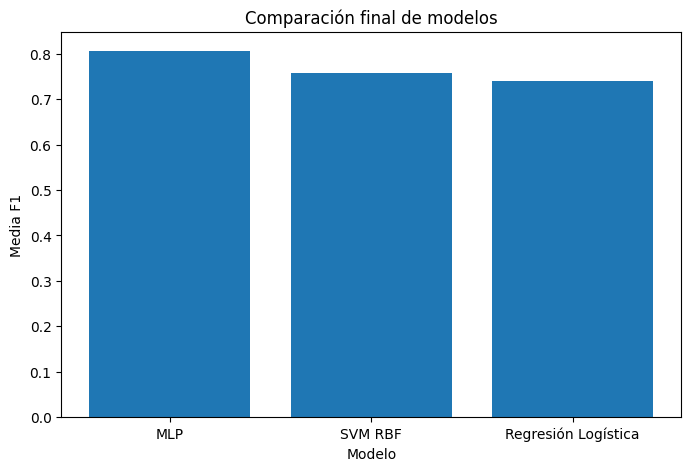

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(resultados['Modelo'], resultados['Media F1'])
plt.title("Comparación final de modelos")
plt.xlabel("Modelo")
plt.ylabel("Media F1")
plt.show()

## **Conclusión**

El objetivo del proyecto fue desarrollar y comparar modelos de clasificación para predecir el riesgo de impago en préstamos personales, utilizando técnicas de aprendizaje estadístico y optimización de hiperparámetros. Con base en los resultados obtenidos, se puede afirmar que dicho objetivo se cumplió de manera satisfactoria.

Se realizó el análisis del dataset y el preprocesamiento de los datos mediante imputación, codificación y escalamiento dentro de un pipeline. Posteriormente, se implementaron y optimizaron los modelos de regresión logística, SVM con kernel RBF y perceptrón multicapa (MLP) utilizando optimización bayesiana.

Al evaluar los modelos mediante validación cruzada (k=10) y la métrica F1, el modelo MLP obtuvo el mejor desempeño (0.8070), seguido por SVM (0.7586) y la regresión logística (0.7408). El MLP presenta el mejor rendimiento promedio, mientras que el SVM muestra menor variabilidad, lo que indica mayor estabilidad.

Estos resultados sugieren que el modelo MLP tiene una mayor capacidad para identificar correctamente a los clientes con riesgo de impago, lo cual es especialmente relevante en el contexto financiero, donde los errores de clasificación pueden generar pérdidas económicas. Esto demuestra la importancia de utilizar modelos capaces de capturar relaciones complejas en problemas financieros.

En conclusión, los modelos no lineales presentan un mejor desempeño en comparación con la regresión logística, lo que indica que las relaciones entre las variables no son completamente lineales. Por lo tanto, el modelo MLP se posiciona como la mejor opción para la predicción del riesgo de impago.

## **Referencias**

Bishop, C. M. (2006). *Pattern recognition and machine learning*. Springer.

Cortes, C., & Vapnik, V. (1995). Support-vector networks. *Machine Learning, 20*(3), 273-297.

Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep learning*. MIT Press.

James, G., Witten, D., Hastie, T., & Tibshirani, R. (2023). *An introduction to statistical learning with applications in Python*. Springer.

Murphy, K. P. (2012). *Machine learning: A probabilistic perspective*. MIT Press.

Rasmussen, C. E., & Williams, C. K. I. (2006). *Gaussian processes for machine learning*. MIT Press.

Lo, T. (2023). *Loan approval classification dataset* [Dataset]. Kaggle. https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data